In [65]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [66]:
sns.set_theme(
    style="whitegrid",
    context="paper",
    palette="PRGn",
    rc={
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "figure.titlesize": 16
    }
)

In [67]:
df = pd.read_csv('diabetes_dataset.csv')

In [68]:
df.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [69]:
categorical_vars = [
    "gender",
    "ethnicity",
    "education_level",
    "income_level",
    "employment_status",
    "smoking_status",
    "family_history_diabetes",
    "hypertension_history",
    "cardiovascular_history",
    "diabetes_stage",
    "diagnosed_diabetes"
]

continuous_vars = [
    "age",
    "alcohol_consumption_per_week",
    "physical_activity_minutes_per_week",
    "diet_score",
    "sleep_hours_per_day",
    "screen_time_hours_per_day",
    "bmi",
    "waist_to_hip_ratio",
    "systolic_bp",
    "diastolic_bp",
    "heart_rate",
    "cholesterol_total",
    "hdl_cholesterol",
    "ldl_cholesterol",
    "triglycerides",
    "glucose_fasting",
    "glucose_postprandial",
    "insulin_level",
    "hba1c",
    "diabetes_risk_score"
]

In [70]:
demographics = [
    "age",
    "gender",
    "ethnicity",
    "education_level",
    "income_level",
    "employment_status"
]

lifestyle = [
    "smoking_status",
    "alcohol_consumption_per_week",
    "physical_activity_minutes_per_week",
    "diet_score",
    "sleep_hours_per_day",
    "screen_time_hours_per_day"
]

medical_history = [
    "family_history_diabetes",
    "hypertension_history",
    "cardiovascular_history"
]

body_metrics = [
    "bmi",
    "waist_to_hip_ratio"
]

vital_signs = [
    "systolic_bp",
    "diastolic_bp",
    "heart_rate"
]

lipid_profile = [
    "cholesterol_total",
    "hdl_cholesterol",
    "ldl_cholesterol",
    "triglycerides"
]

diabetes_biomarkers = [
    "glucose_fasting",
    "glucose_postprandial",
    "insulin_level",
    "hba1c"
]

diabetes_outcomes = [
    "diabetes_risk_score",
    "diabetes_stage",
    "diagnosed_diabetes"
]

target = "diagnosed_diabetes"

## Quality of the data

In [71]:
df.isnull().sum().sort_values(ascending=False)

age                                   0
waist_to_hip_ratio                    0
diabetes_stage                        0
diabetes_risk_score                   0
hba1c                                 0
insulin_level                         0
glucose_postprandial                  0
glucose_fasting                       0
triglycerides                         0
ldl_cholesterol                       0
hdl_cholesterol                       0
cholesterol_total                     0
heart_rate                            0
diastolic_bp                          0
systolic_bp                           0
bmi                                   0
gender                                0
cardiovascular_history                0
hypertension_history                  0
family_history_diabetes               0
screen_time_hours_per_day             0
sleep_hours_per_day                   0
diet_score                            0
physical_activity_minutes_per_week    0
alcohol_consumption_per_week          0


<Axes: xlabel='diagnosed_diabetes', ylabel='count'>

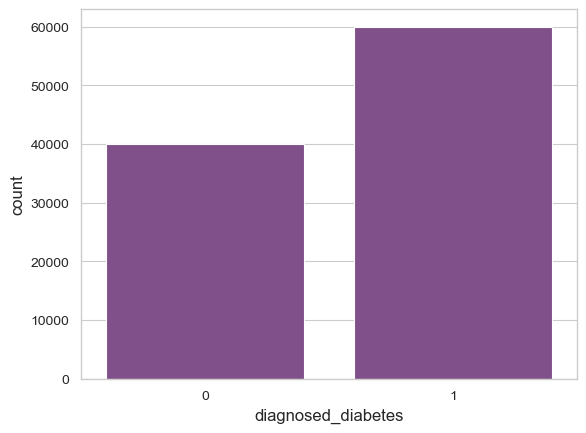

In [72]:
sns.countplot(data=df, x="diagnosed_diabetes")

<Axes: xlabel='diabetes_stage', ylabel='count'>

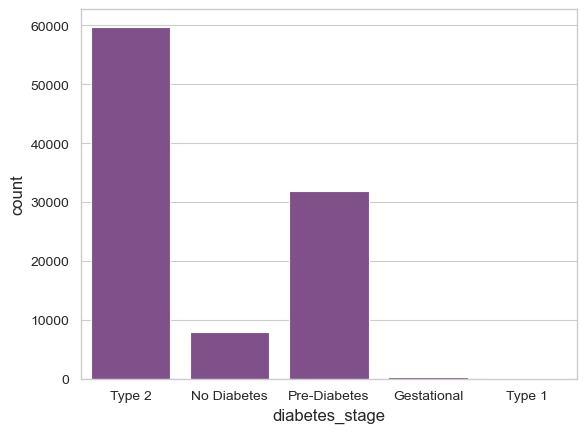

In [73]:
sns.countplot(data=df, x="diabetes_stage")

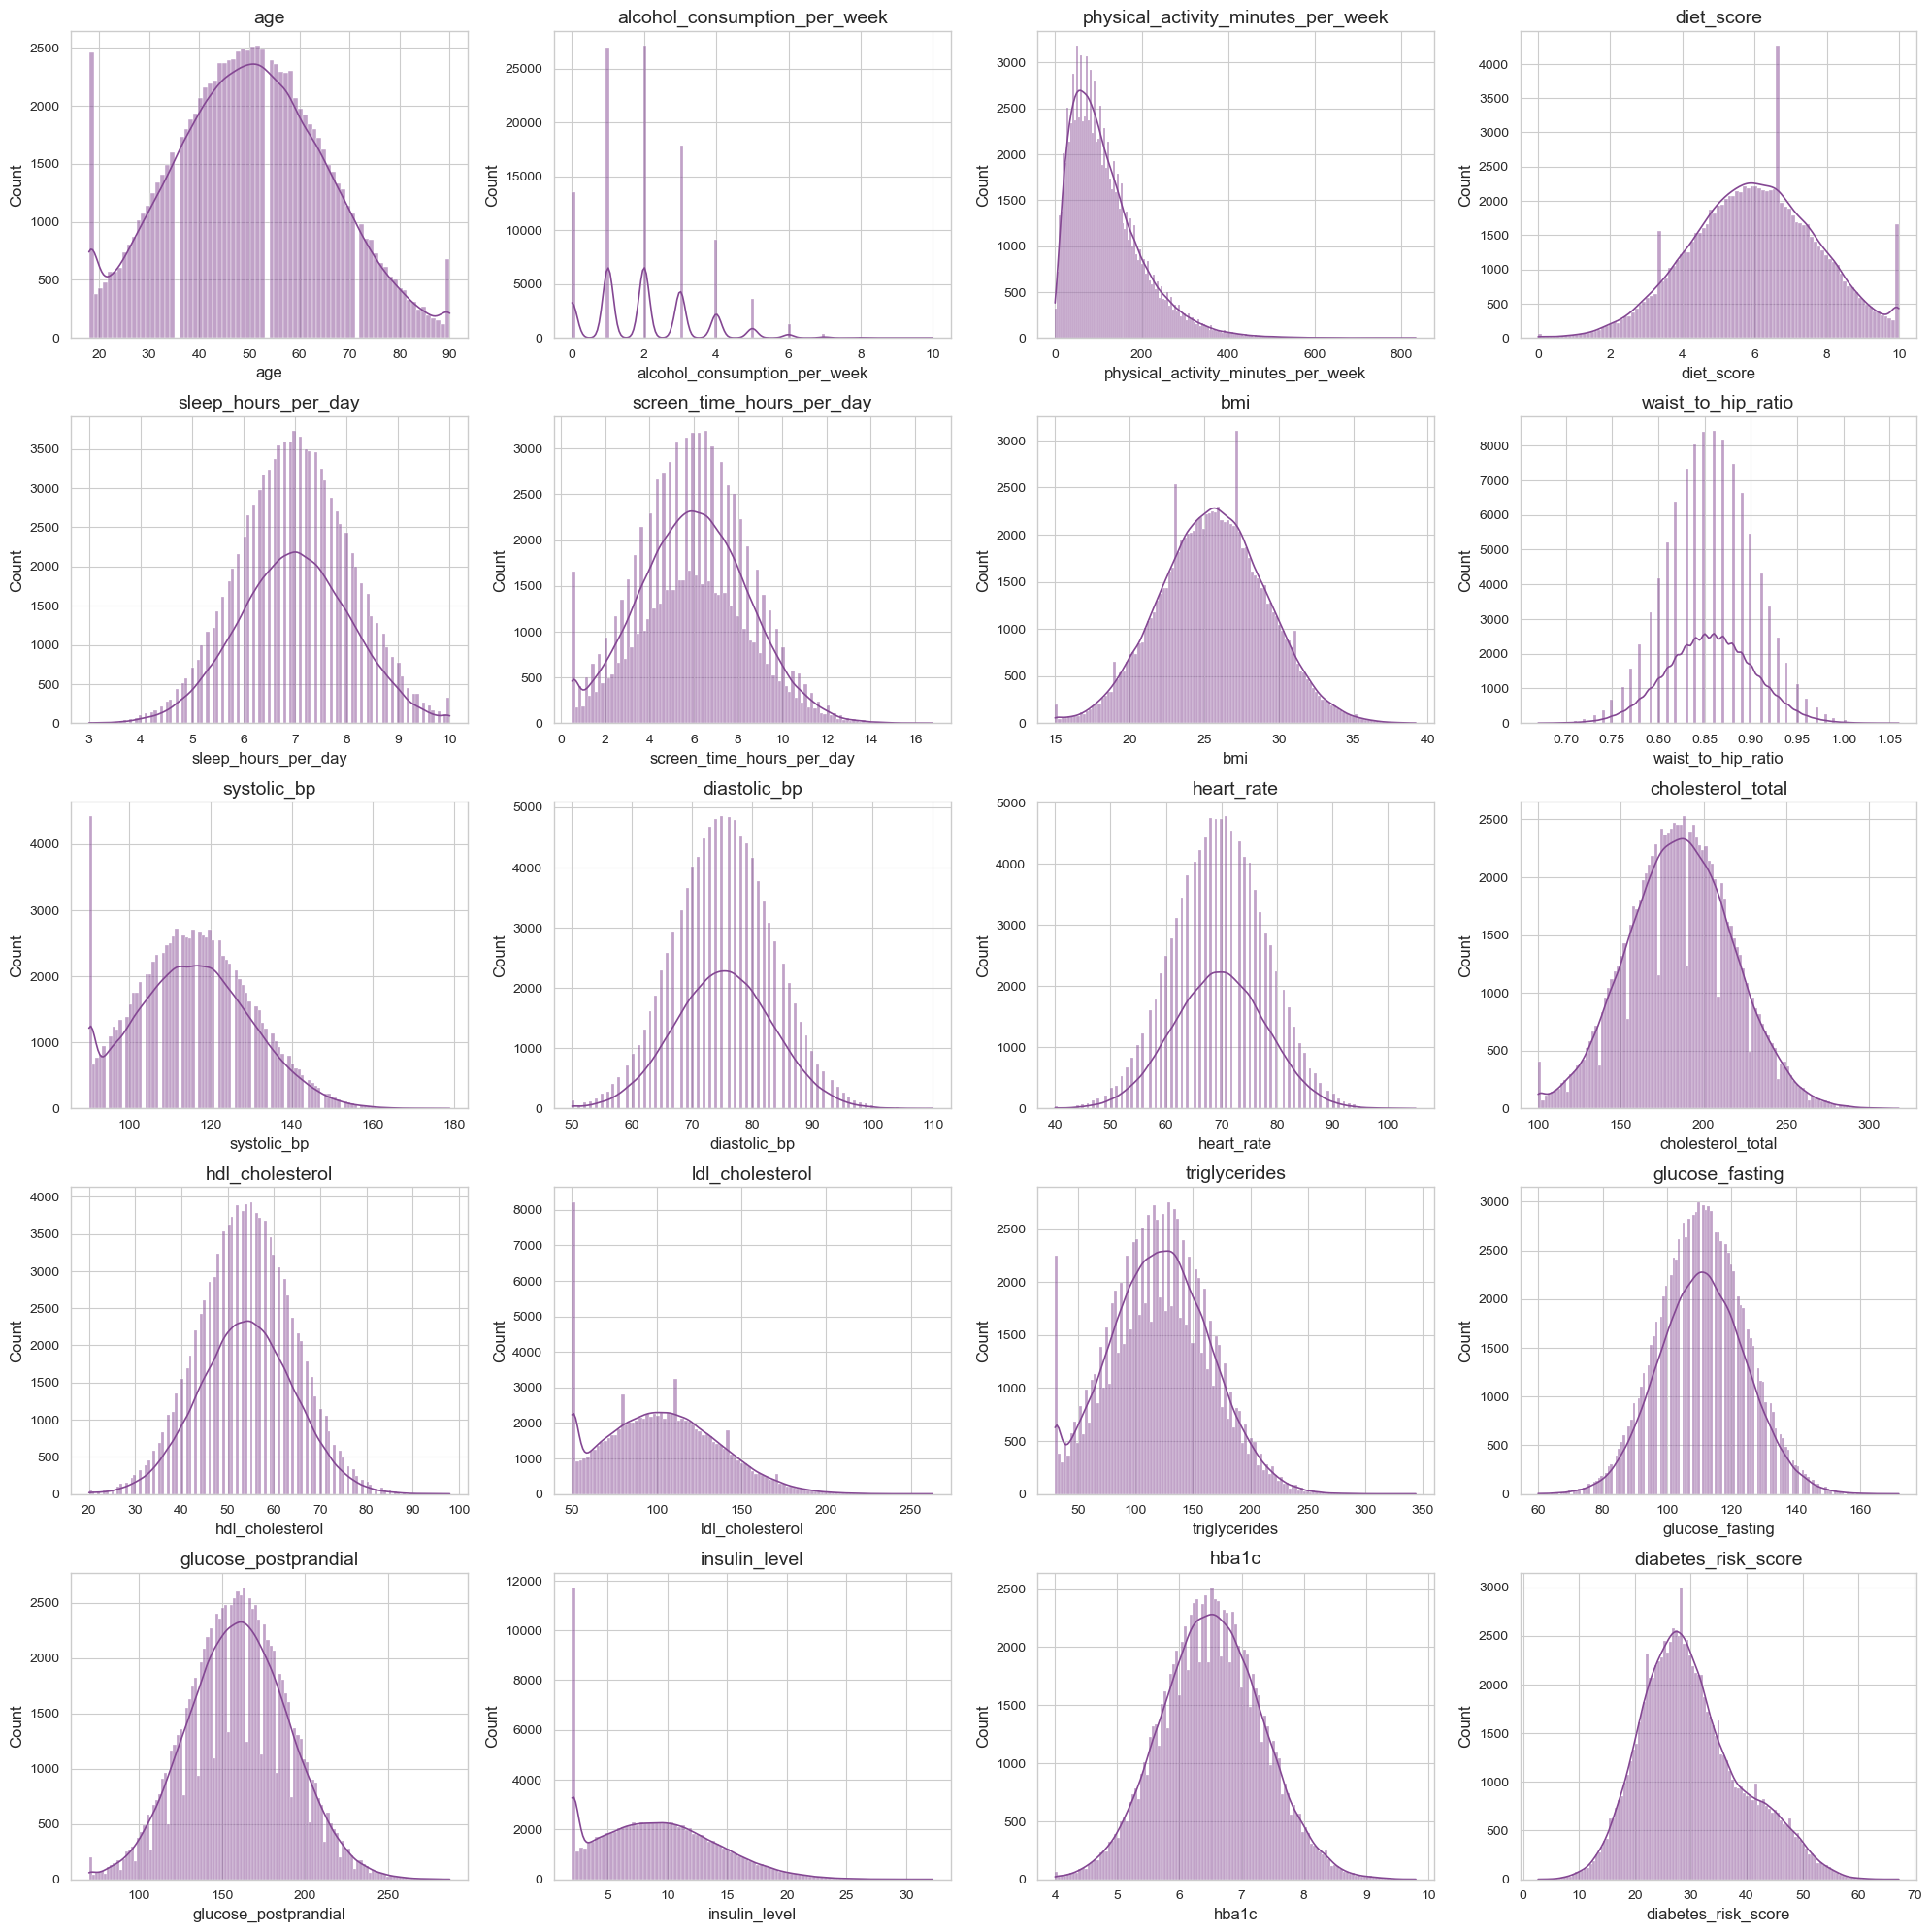

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

cols = 4
rows = math.ceil(len(continuous_vars) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()

for i, col in enumerate(continuous_vars):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)

for i in range(len(continuous_vars), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

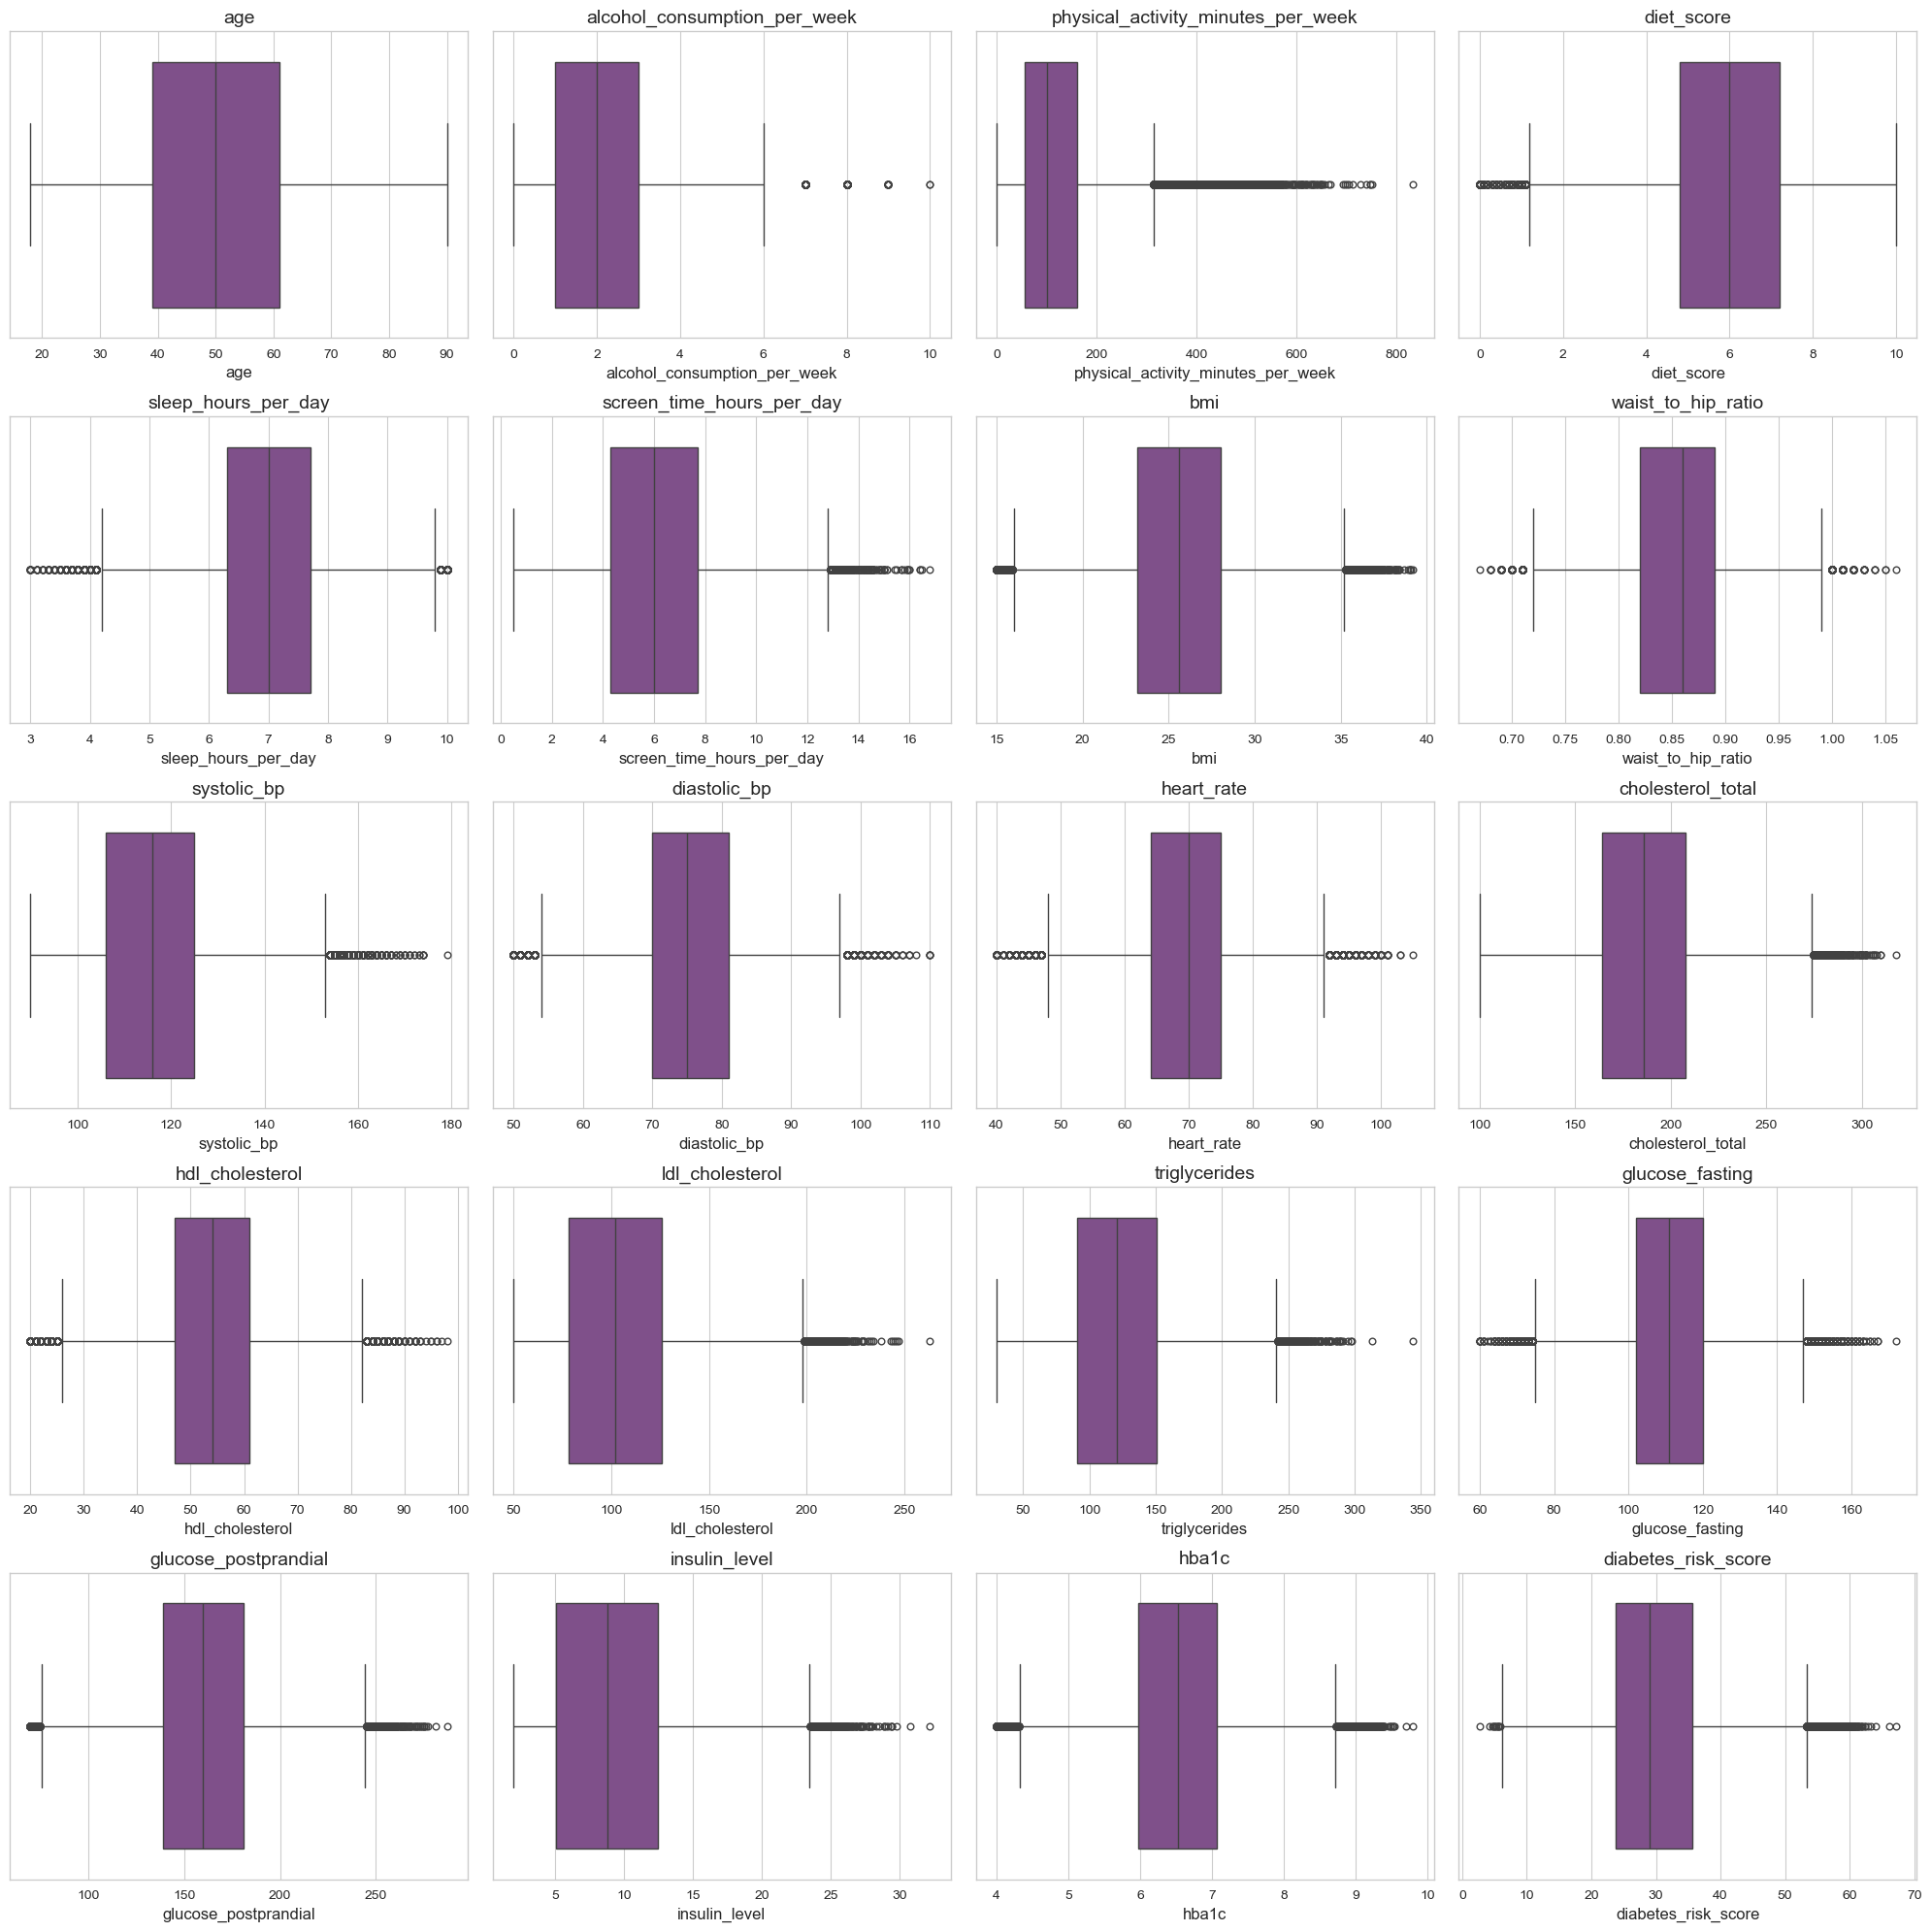

In [75]:
cols = 4
rows = math.ceil(len(continuous_vars) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()

for i, col in enumerate(continuous_vars):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

for i in range(len(continuous_vars), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

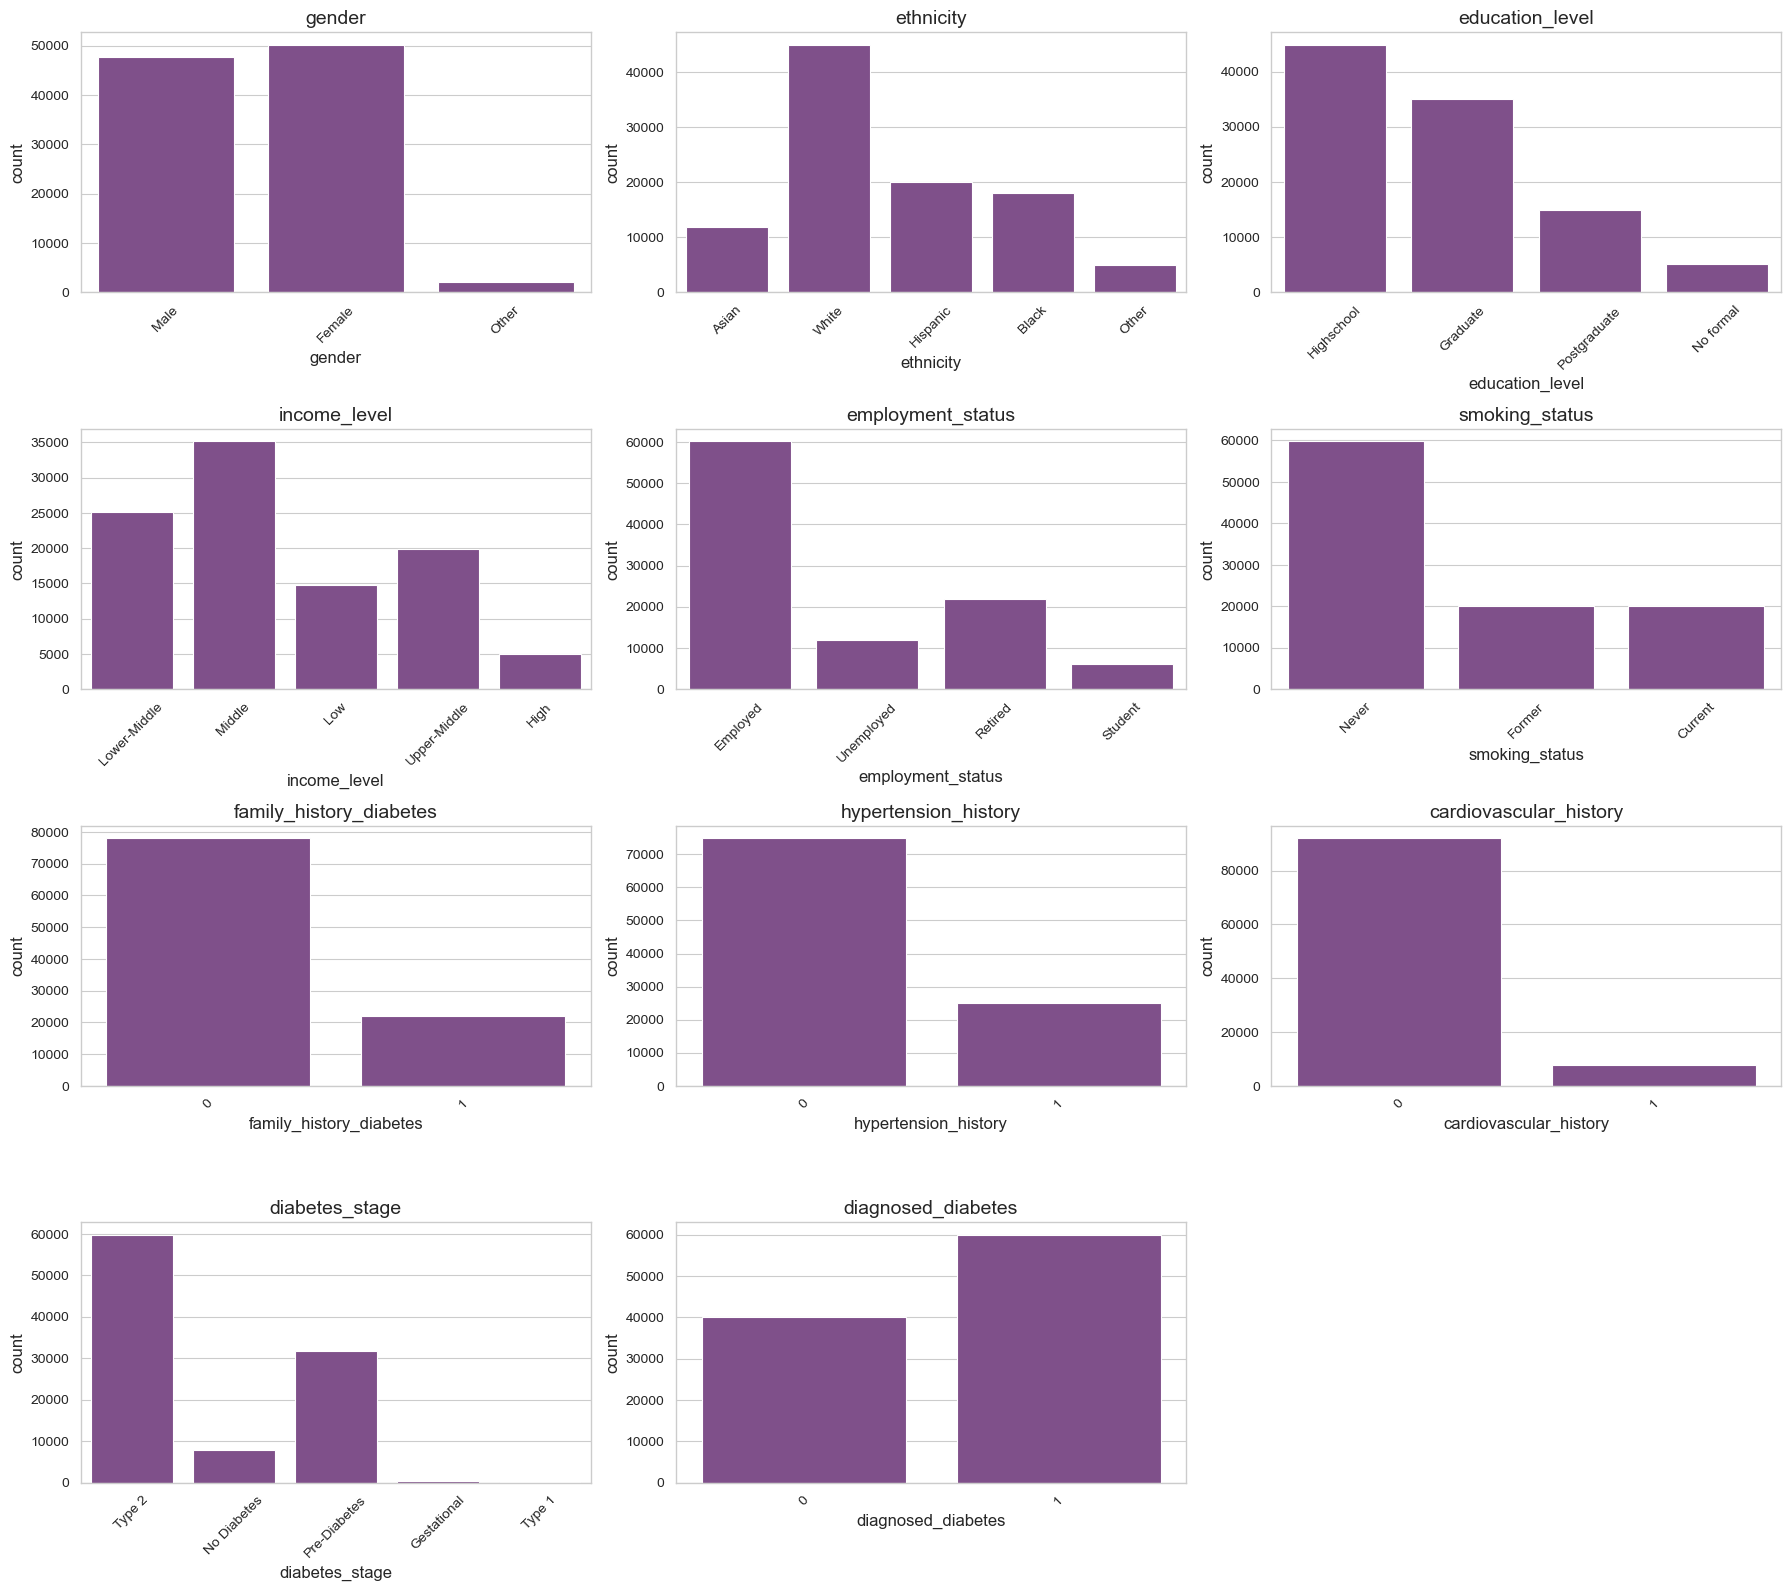

In [76]:
cols = 3
rows = math.ceil(len(categorical_vars) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flatten()

for i, col in enumerate(categorical_vars):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

for i in range(len(categorical_vars), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

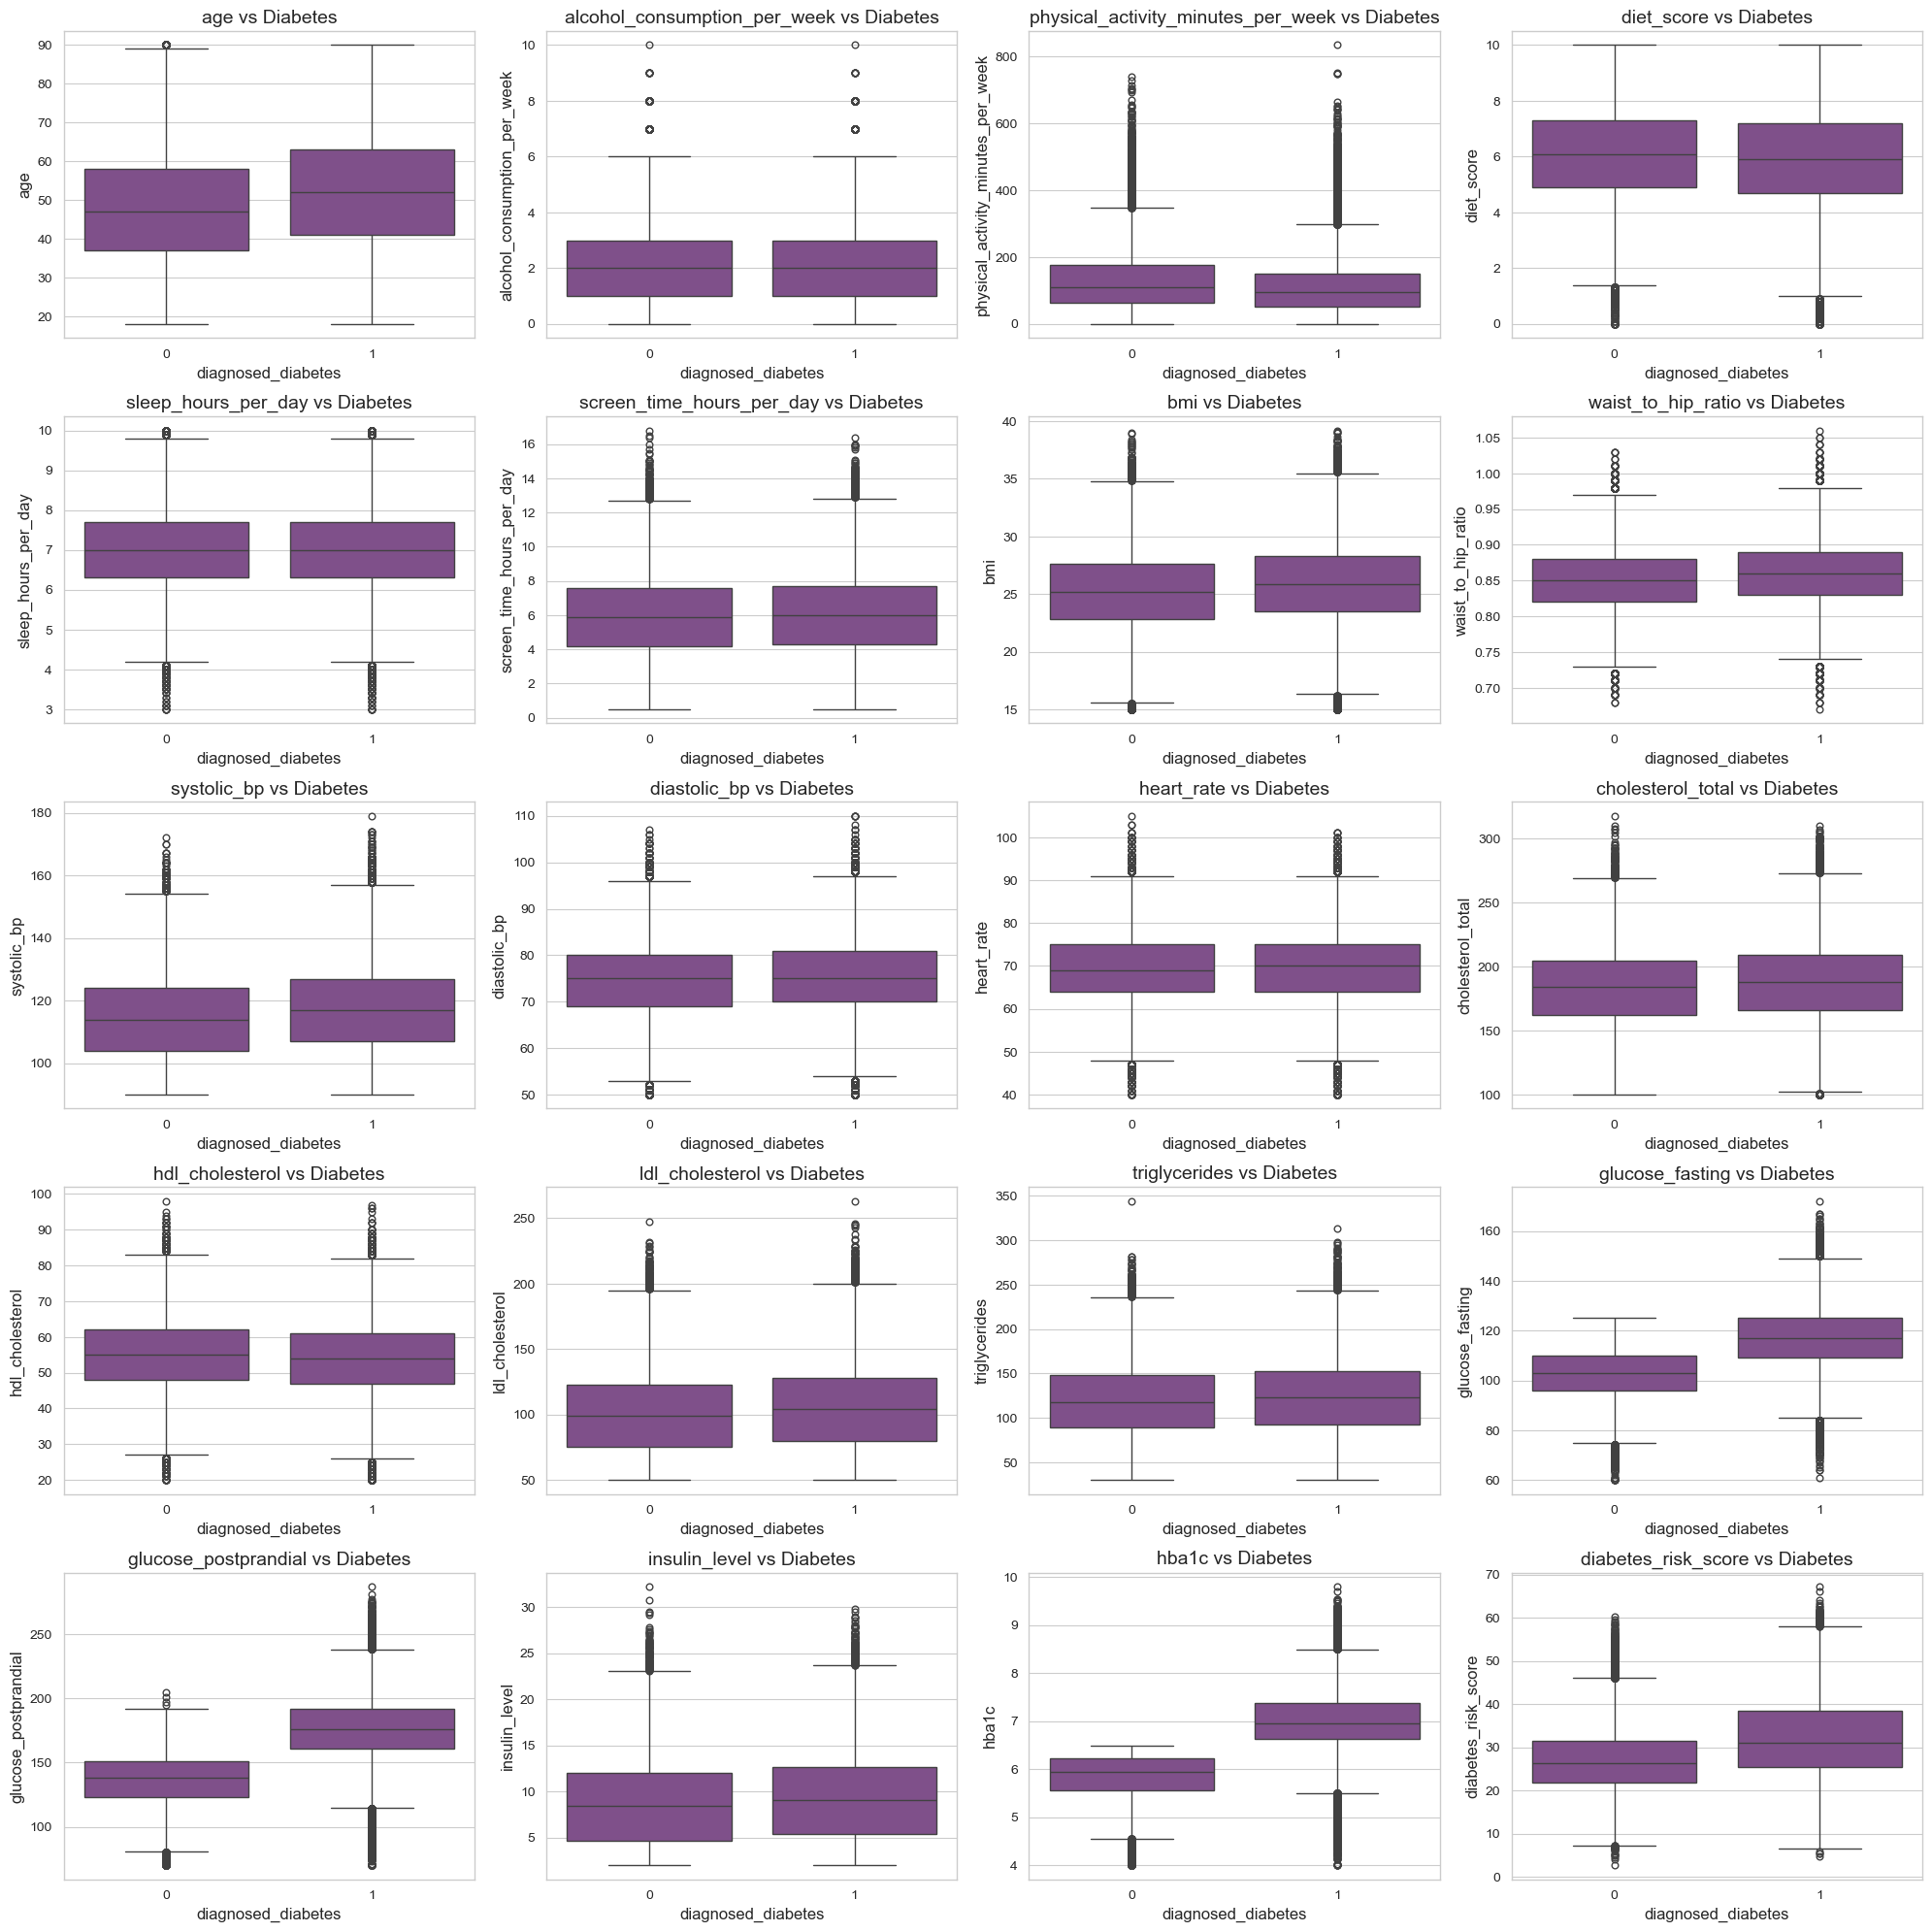

In [77]:
cols = 4
rows = math.ceil(len(continuous_vars) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()

for i, col in enumerate(continuous_vars):
    sns.boxplot(data=df, x="diagnosed_diabetes", y=col, ax=axes[i])
    axes[i].set_title(f"{col} vs Diabetes")

for i in range(len(continuous_vars), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

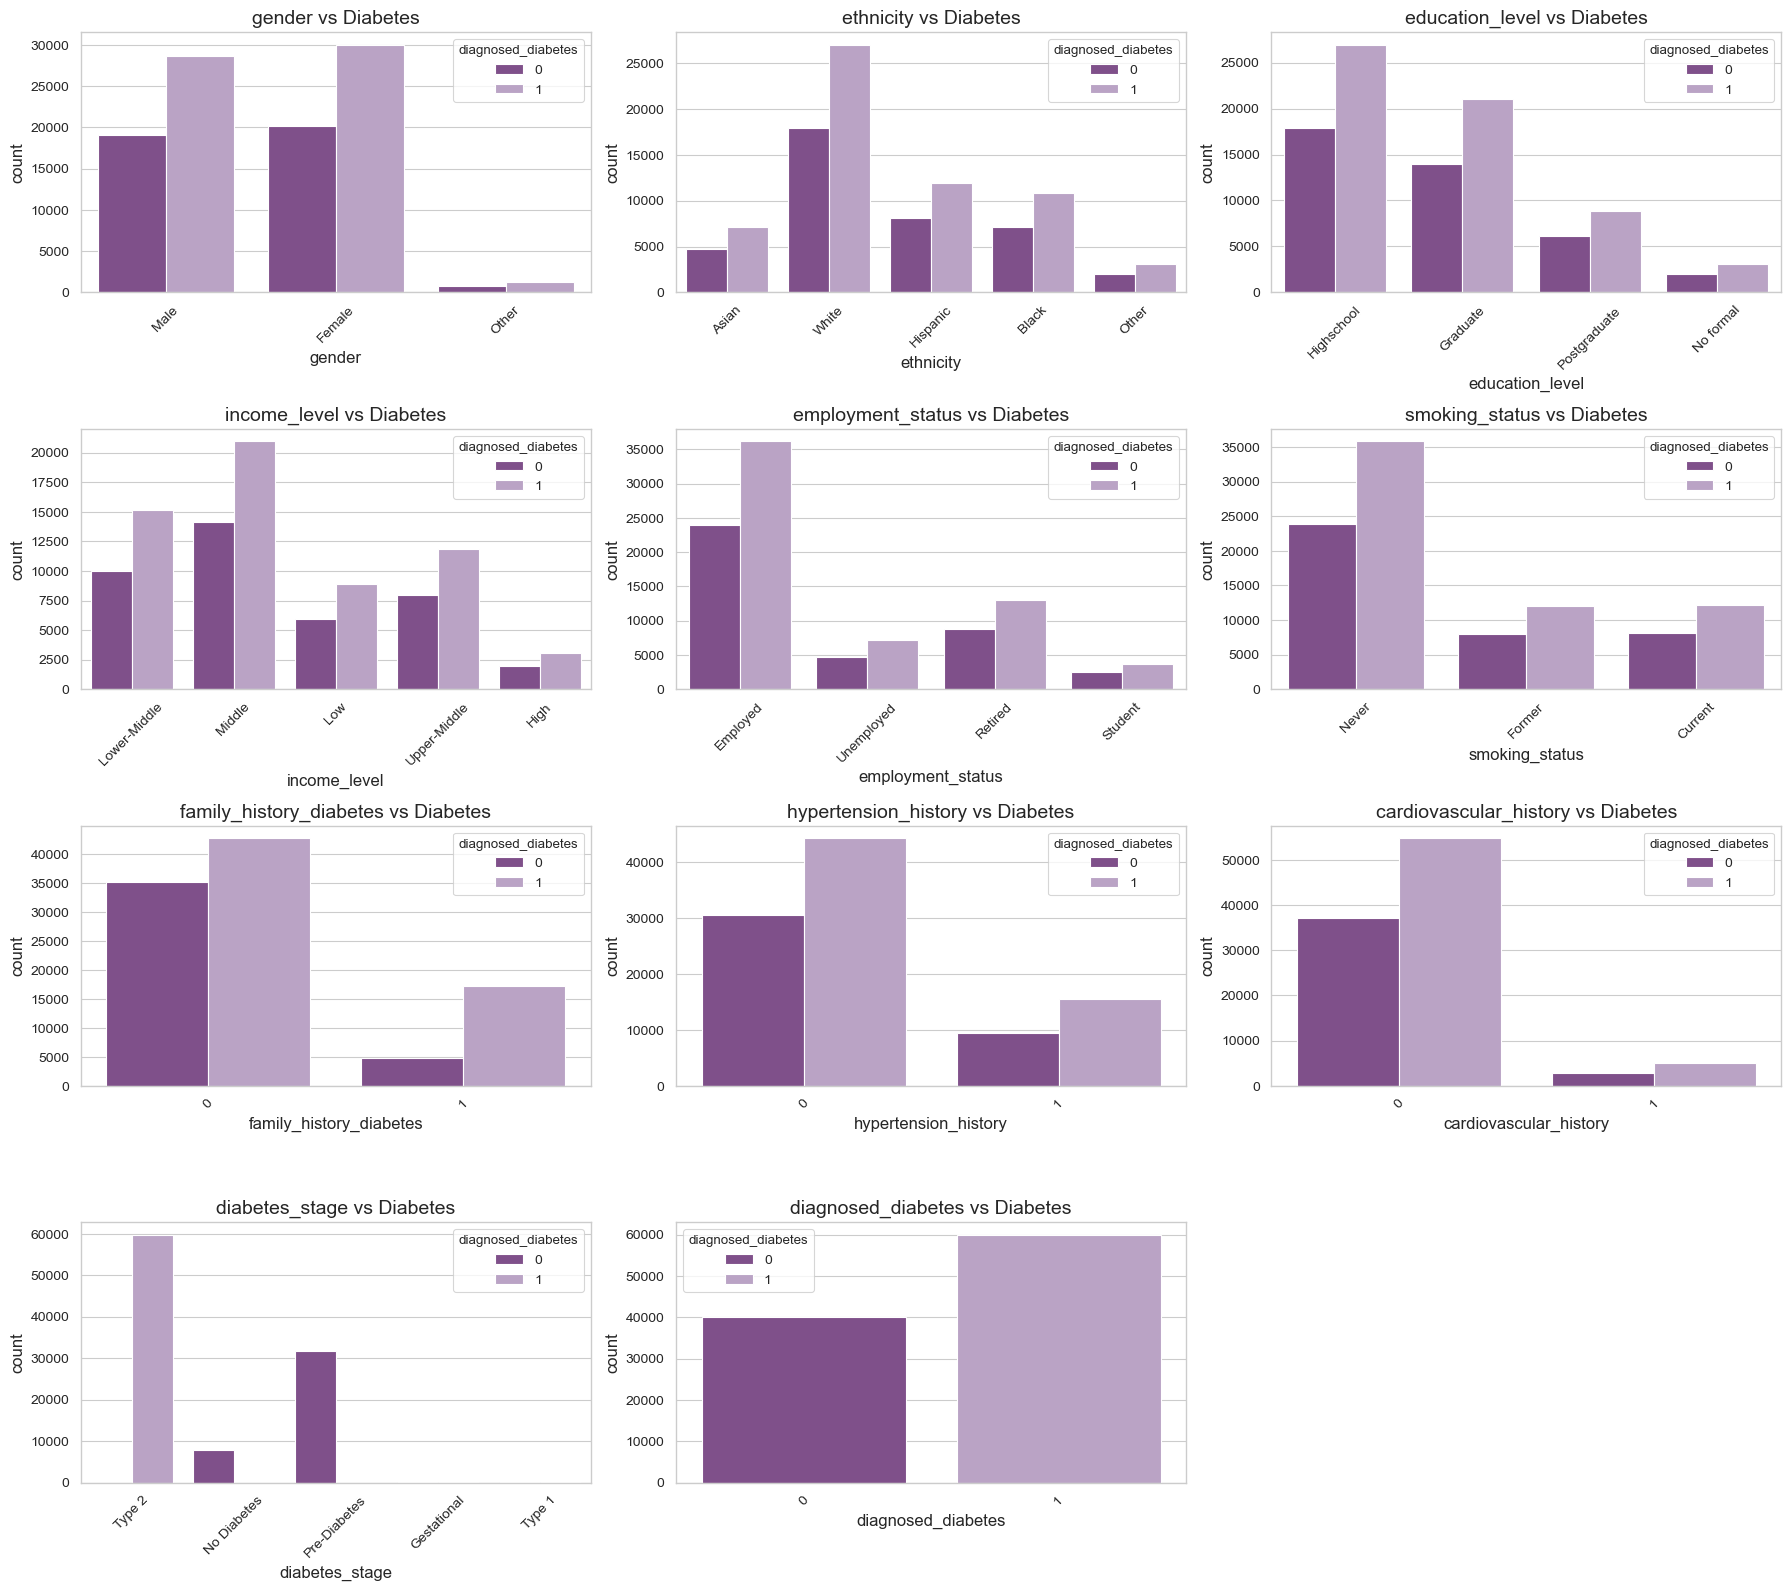

In [78]:
cols = 3
rows = math.ceil(len(categorical_vars) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flatten()

for i, col in enumerate(categorical_vars):
    sns.countplot(data=df, x=col, hue="diagnosed_diabetes", ax=axes[i])
    axes[i].set_title(f"{col} vs Diabetes")
    axes[i].tick_params(axis='x', rotation=45)

for i in range(len(categorical_vars), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

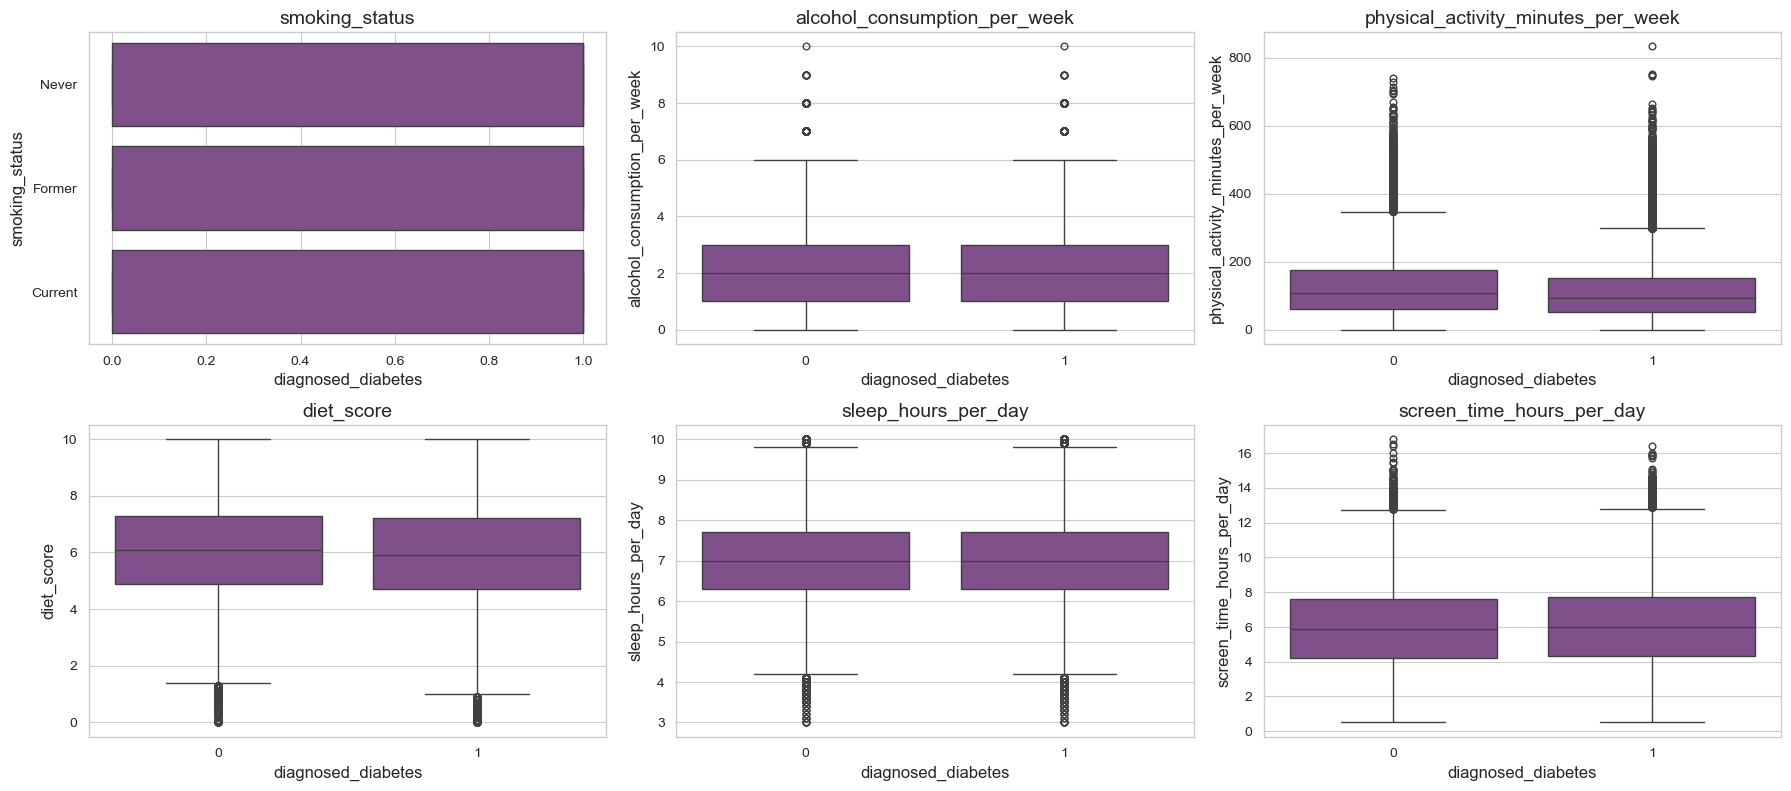

In [79]:
cols = 3
rows = math.ceil(len(lifestyle) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flatten()

for i, col in enumerate(lifestyle):
    sns.boxplot(data=df, x="diagnosed_diabetes", y=col, ax=axes[i])
    axes[i].set_title(col)

for i in range(len(lifestyle), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

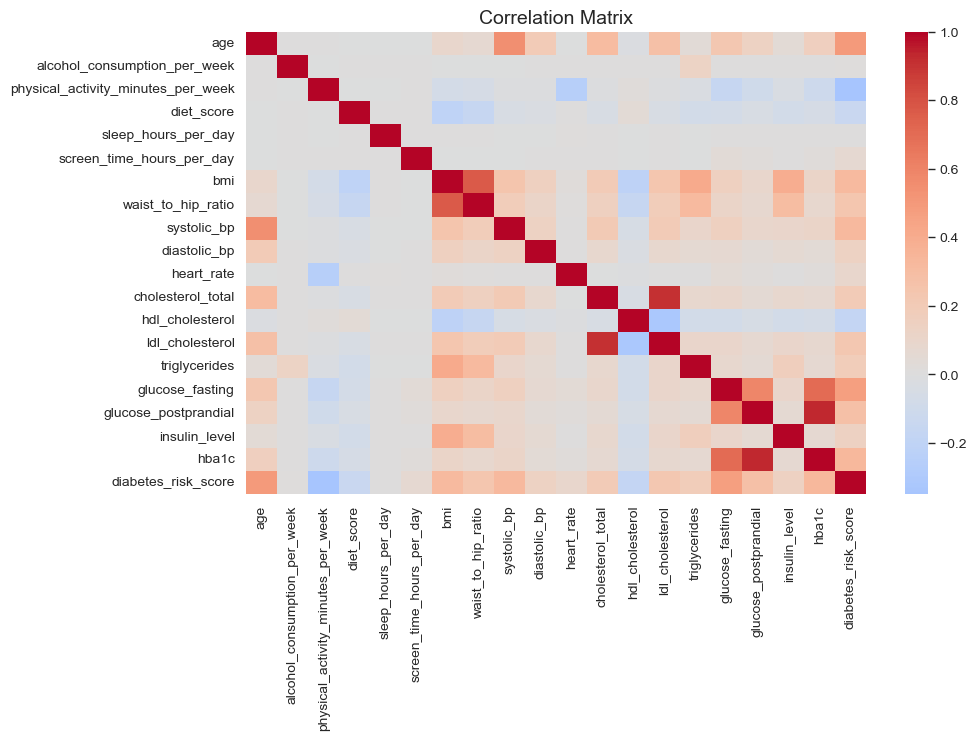

In [80]:
plt.figure(figsize=(10,6))
sns.heatmap(df[continuous_vars].corr(), cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

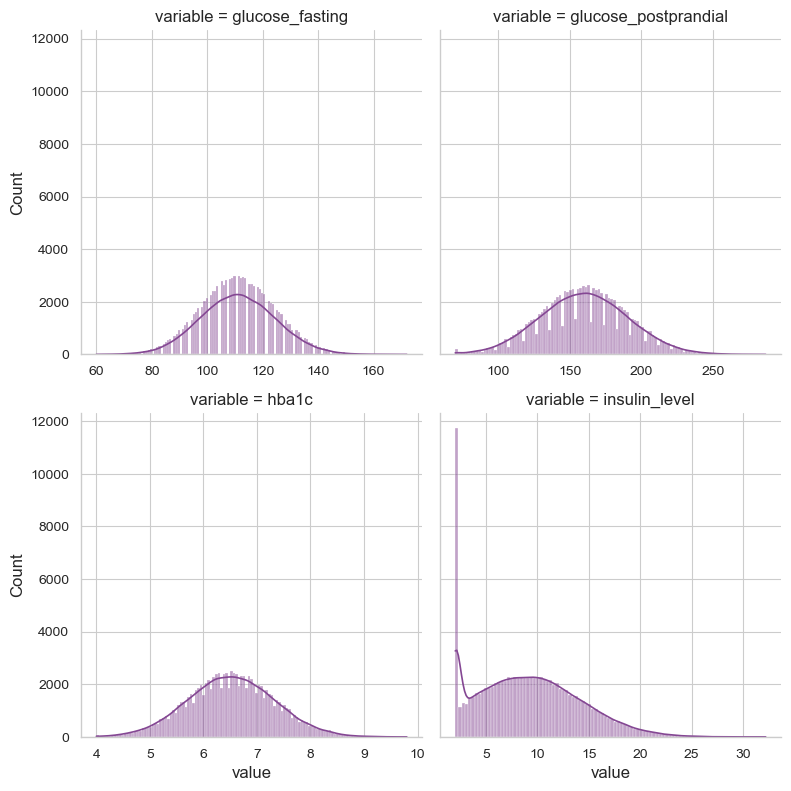

In [81]:
biomarkers = ["glucose_fasting","glucose_postprandial","hba1c","insulin_level"]

g = sns.FacetGrid(
    df.melt(id_vars="diagnosed_diabetes", value_vars=biomarkers),
    col="variable",
    col_wrap=2,
    sharex=False,
    height=4
)

g.map(sns.histplot, "value", kde=True)

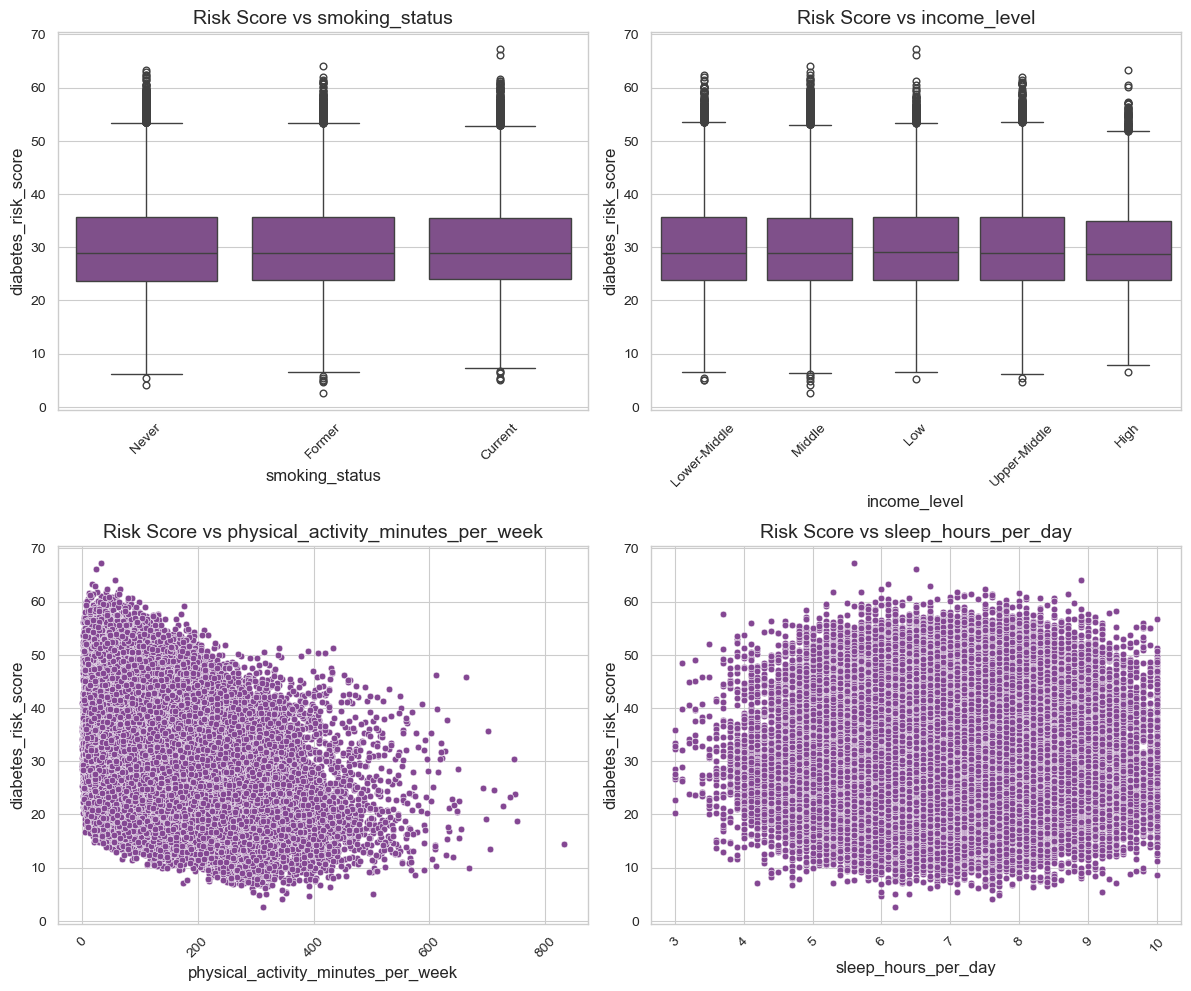

In [82]:
lifestyle_vars = [
    "smoking_status",
    "income_level",
    "physical_activity_minutes_per_week",
    "sleep_hours_per_day"
]

import math

cols = 2
rows = math.ceil(len(lifestyle_vars) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(12, rows*5))
axes = axes.flatten()

for i, col in enumerate(lifestyle_vars):
    
    if df[col].dtype == "object":
        sns.boxplot(data=df, x=col, y="diabetes_risk_score", ax=axes[i])
    else:
        sns.scatterplot(data=df, x=col, y="diabetes_risk_score", ax=axes[i])
    
    axes[i].set_title(f"Risk Score vs {col}")
    axes[i].tick_params(axis='x', rotation=45)

for i in range(len(lifestyle_vars), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

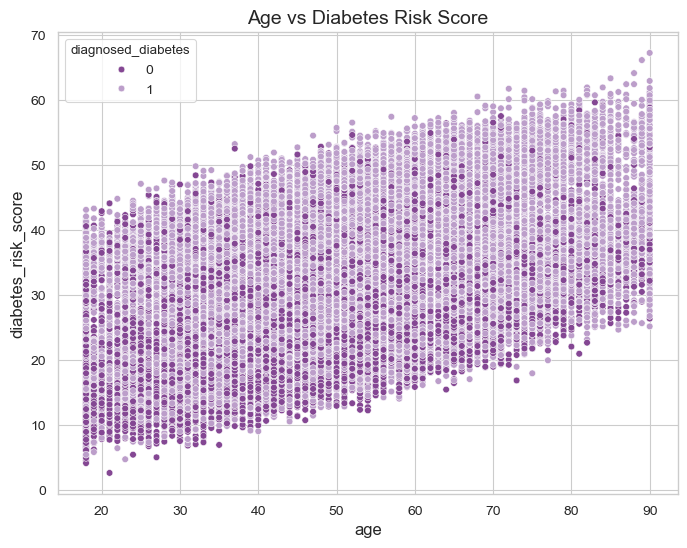

In [83]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="age",
    y="diabetes_risk_score",
    hue="diagnosed_diabetes"
)

plt.title("Age vs Diabetes Risk Score")
plt.show()

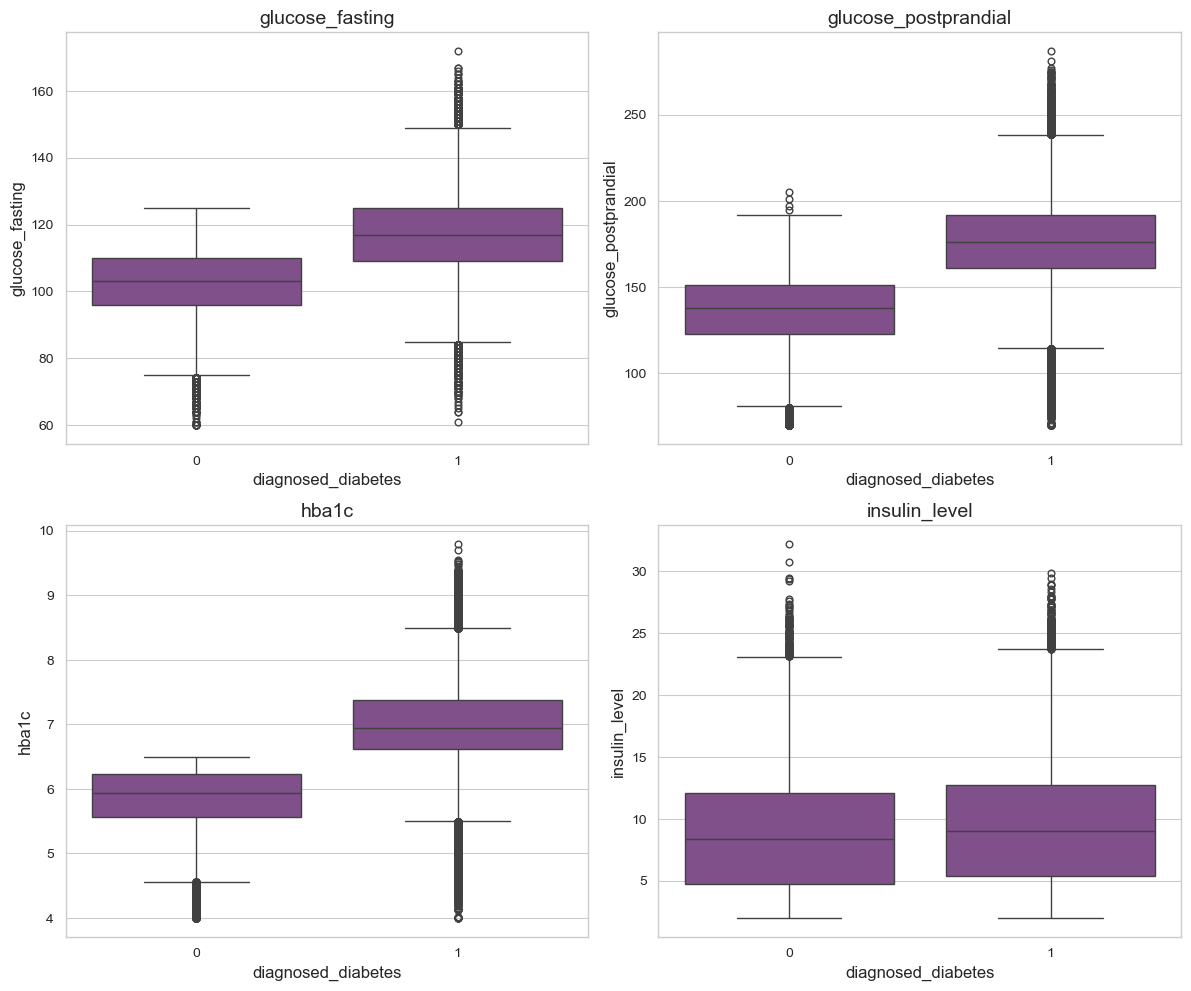

In [84]:
biomarkers = ["glucose_fasting","glucose_postprandial","hba1c","insulin_level"]

cols = 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(12,10))
axes = axes.flatten()

for i, col in enumerate(biomarkers):
    
    sns.boxplot(
        data=df,
        x="diagnosed_diabetes",
        y=col,
        ax=axes[i]
    )
    
    axes[i].set_title(col)

plt.tight_layout()
plt.show()